In [1]:
# =============================================================================
# Fase 3 - Machine Learning Clasico: Random Forest
# Dataset: Adult Census Income (UCI Machine Learning Repository)
# =============================================================================
# Este notebook implementa y evalua un clasificador Random Forest sobre el
# dataset Adult preprocesado en la Fase 1, y lo compara directamente contra
# el mejor modelo de redes neuronales obtenido en la Fase 2 (Modelo B).
#
# Random Forest es un metodo de ensamble basado en el concepto de bagging:
# construye multiples arboles de decision sobre subconjuntos aleatorios de
# los datos y las variables, y combina sus predicciones por votacion mayoritaria.
# Esta estrategia reduce la varianza respecto a un arbol individual y produce
# modelos mas robustos y generalizables.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style("whitegrid")

os.makedirs('graficas', exist_ok=True)

print("Librerias cargadas correctamente.")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
import sklearn; print(f"scikit-learn: {sklearn.__version__}")

Librerias cargadas correctamente.
pandas     : 3.0.2
numpy      : 2.4.4
scikit-learn: 1.8.0


In [2]:
# =============================================================================
# Carga de datos preprocesados desde la Fase 1
# =============================================================================

X_train = pd.read_csv('../datos/X_train.csv')
X_test  = pd.read_csv('../datos/X_test.csv')
y_train = pd.read_csv('../datos/y_train.csv').values.ravel()
y_test  = pd.read_csv('../datos/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nDistribucion de clases en y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribucion de clases en y_test : {dict(zip(*np.unique(y_test, return_counts=True)))}")

X_train : (39073, 97)
X_test  : (9769, 97)
y_train : (39073,)
y_test  : (9769,)

Distribucion de clases en y_train: {np.int64(0): np.int64(29724), np.int64(1): np.int64(9349)}
Distribucion de clases en y_test : {np.int64(0): np.int64(7431), np.int64(1): np.int64(2338)}


Funcion de evaluacion definida.

Analizando efecto de n_estimators...
  n_estimators=  10 -> F1 validacion cruzada: 0.6421
  n_estimators=  25 -> F1 validacion cruzada: 0.6628
  n_estimators=  50 -> F1 validacion cruzada: 0.6611
  n_estimators= 100 -> F1 validacion cruzada: 0.6638
  n_estimators= 150 -> F1 validacion cruzada: 0.6661
  n_estimators= 200 -> F1 validacion cruzada: 0.6665


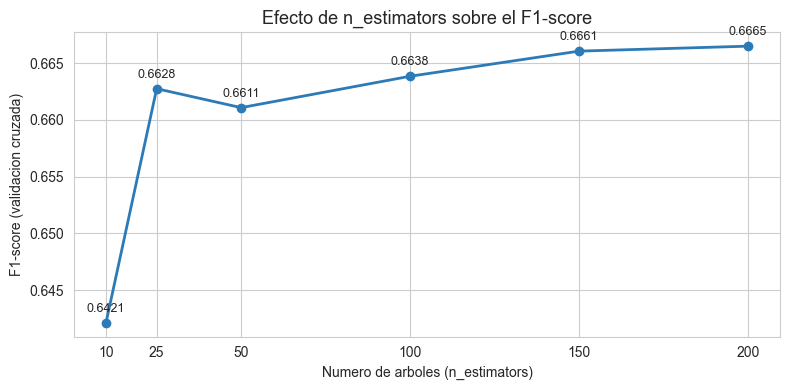

Grafica guardada.


In [3]:
# =============================================================================
# Funcion de evaluacion compartida
# =============================================================================

def evaluar_modelo(nombre, y_real, y_pred, carpeta='graficas'):
    acc  = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred, zero_division=0)
    rec  = recall_score(y_real, y_pred, zero_division=0)
    f1   = f1_score(y_real, y_pred, zero_division=0)
    cm   = confusion_matrix(y_real, y_pred)

    print(f"\n{'=' * 50}")
    print(f"METRICAS - {nombre}")
    print(f"{'=' * 50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusion - {nombre}')
    plt.tight_layout()
    plt.savefig(f'{carpeta}/confusion_{nombre.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

print("Funcion de evaluacion definida.")

# =============================================================================
# Analisis del efecto de n_estimators
# =============================================================================
# n_estimators es el hiperparametro mas importante de Random Forest: define
# cuantos arboles se construyen. A mayor numero de arboles, el modelo es mas
# estable pero mas costoso computacionalmente. Se evalua el efecto sobre
# el accuracy de validacion cruzada para elegir un valor adecuado.
# =============================================================================

print("\nAnalizando efecto de n_estimators...")
estimadores = [10, 25, 50, 100, 150, 200]
scores_estimadores = []

for n in estimadores:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    score = cross_val_score(rf, X_train, y_train, cv=3,
                            scoring='f1', n_jobs=-1).mean()
    scores_estimadores.append(score)
    print(f"  n_estimators={n:4d} -> F1 validacion cruzada: {score:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(estimadores, scores_estimadores, marker='o', color='#2c7bb6', linewidth=2)
ax.set_xlabel('Numero de arboles (n_estimators)')
ax.set_ylabel('F1-score (validacion cruzada)')
ax.set_title('Efecto de n_estimators sobre el F1-score')
ax.set_xticks(estimadores)
for x, y in zip(estimadores, scores_estimadores):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graficas/efecto_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

Analizando efecto de max_depth...
  max_depth=5     -> F1 validacion cruzada: 0.5159
  max_depth=10    -> F1 validacion cruzada: 0.6397
  max_depth=15    -> F1 validacion cruzada: 0.6576
  max_depth=20    -> F1 validacion cruzada: 0.6649
  max_depth=None  -> F1 validacion cruzada: 0.6638


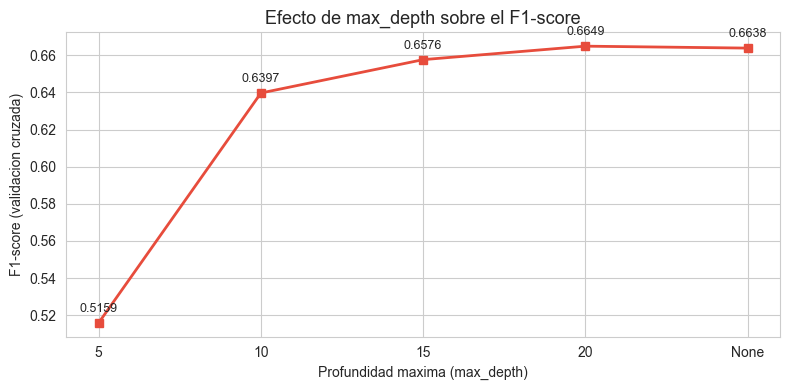

Grafica guardada.

Entrenando modelo Random Forest final...
Entrenamiento completado.

METRICAS - Random Forest
  Accuracy  : 0.8555  (85.55%)
  Precision : 0.7006
  Recall    : 0.6916
  F1-score  : 0.6961


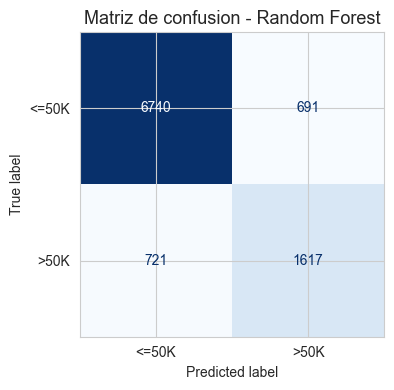

In [4]:
# =============================================================================
# Analisis del efecto de max_depth
# =============================================================================
# max_depth controla la profundidad maxima de cada arbol. Arboles muy
# profundos pueden sobreajustarse a los datos de entrenamiento, mientras
# que arboles muy poco profundos pueden no capturar patrones suficientes.
# None significa que los arboles crecen hasta que todas las hojas sean puras.
# =============================================================================

print("Analizando efecto de max_depth...")
profundidades = [5, 10, 15, 20, None]
scores_profundidad = []
etiquetas_prof = ['5', '10', '15', '20', 'None']

for prof in profundidades:
    rf = RandomForestClassifier(n_estimators=100, max_depth=prof,
                                random_state=42, n_jobs=-1)
    score = cross_val_score(rf, X_train, y_train, cv=3,
                            scoring='f1', n_jobs=-1).mean()
    scores_profundidad.append(score)
    print(f"  max_depth={str(prof):5s} -> F1 validacion cruzada: {score:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(etiquetas_prof, scores_profundidad, marker='s',
        color='#e74c3c', linewidth=2)
ax.set_xlabel('Profundidad maxima (max_depth)')
ax.set_ylabel('F1-score (validacion cruzada)')
ax.set_title('Efecto de max_depth sobre el F1-score')
for x, y in zip(etiquetas_prof, scores_profundidad):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graficas/efecto_max_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

# =============================================================================
# Entrenamiento del modelo Random Forest final
# =============================================================================
# Con base en el analisis de hiperparametros se elige:
#   n_estimators = 100 : punto de estabilizacion del F1
#   max_depth    = None: arboles completos producen mejor F1
#   min_samples_split = 5 : evita divisiones con muy pocos datos
#   class_weight = 'balanced': ajusta los pesos de las clases
#                  inversamente proporcional a su frecuencia, lo que
#                  ayuda a manejar el desbalance 76/24 del dataset
# =============================================================================

print("\nEntrenando modelo Random Forest final...")
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
print("Entrenamiento completado.")

y_pred_rf = rf_final.predict(X_test)
resultados_rf = evaluar_modelo('Random Forest', y_test, y_pred_rf)

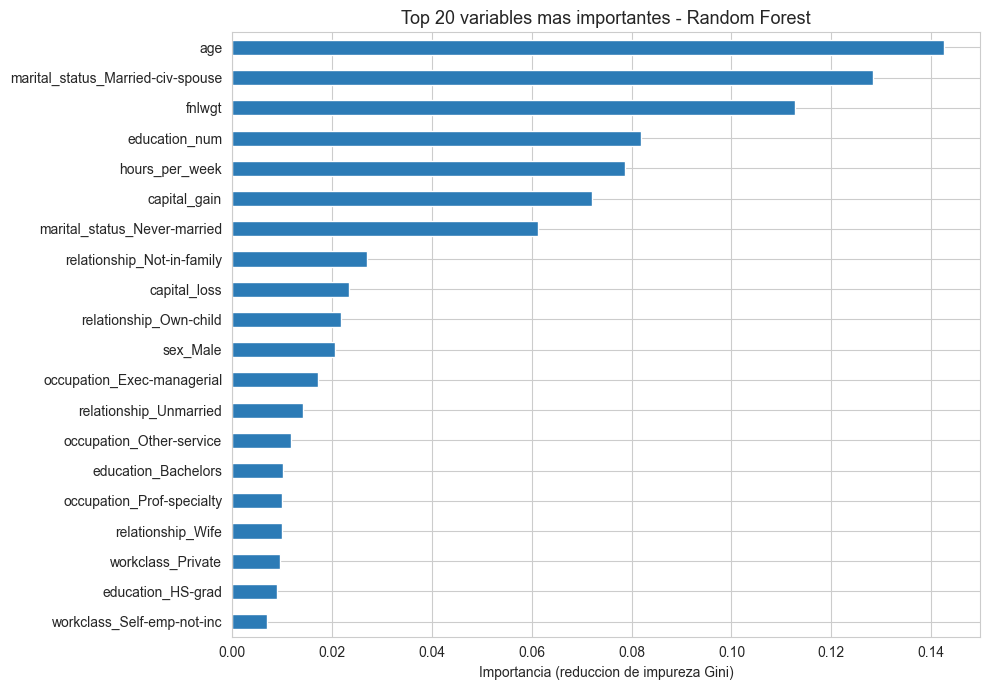

Grafica guardada.
COMPARATIVO FINAL: RANDOM FOREST vs MEJOR RED NEURONAL


,accuracy,precision,recall,f1
modelo,,,,
Modelo B (Red Neuronal),0.8513,0.7365,0.5894,0.6548
Random Forest,0.8555,0.7006,0.6916,0.6961


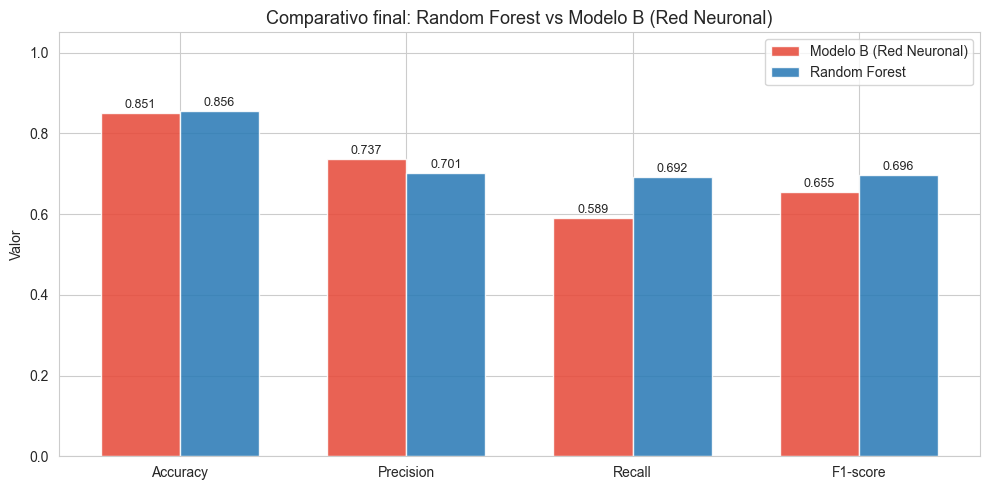

Grafica guardada.


In [5]:
# =============================================================================
# Importancia de variables
# =============================================================================
# Random Forest calcula la importancia de cada variable como la reduccion
# promedio de impureza (Gini) que produce esa variable a lo largo de todos
# los arboles del bosque. Las variables mas importantes son las que mas
# contribuyen a separar las clases en el conjunto de datos.
# =============================================================================

importancias = pd.Series(rf_final.feature_importances_,
                         index=X_train.columns)
top20 = importancias.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='#2c7bb6', edgecolor='white')
ax.set_title('Top 20 variables mas importantes - Random Forest')
ax.set_xlabel('Importancia (reduccion de impureza Gini)')
plt.tight_layout()
plt.savefig('graficas/importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

# =============================================================================
# Comparativo final: Random Forest vs Redes Neuronales
# =============================================================================

resultados_modelo_B = {
    'modelo': 'Modelo B (Red Neuronal)',
    'accuracy': 0.8513,
    'precision': 0.7365,
    'recall': 0.5894,
    'f1': 0.6548
}

df_comparativo = pd.DataFrame([
    resultados_modelo_B,
    resultados_rf
]).set_index('modelo').round(4)

print("=" * 60)
print("COMPARATIVO FINAL: RANDOM FOREST vs MEJOR RED NEURONAL")
print("=" * 60)
display(df_comparativo)

# Grafica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
metricas = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metricas))
ancho = 0.35
colores = ['#e74c3c', '#2c7bb6']

for i, (idx, row) in enumerate(df_comparativo.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho,
                    label=idx, color=colores[i], alpha=0.88)
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.005,
                f'{barra.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + ancho / 2)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-score'])
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.set_title('Comparativo final: Random Forest vs Modelo B (Red Neuronal)')
ax.legend()
plt.tight_layout()
plt.savefig('graficas/comparativo_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")